# Churn Prediction

This notebook will establishe the predictive baseline for `Beyond Churn`.

The goal is to answer:

> **Which customers are most likely to churn?**

I will build and evaluate churn-risk models before comparing predictive churn risk with causal treatment responsiveness in later notebooks.

This distinction is central to the project:

> **The customer most likely to churn is not necessarily the customer most likely to be saved.**

### Imports

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openml

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.calibration import calibration_curve, CalibratedClassifierCV

from catboost import CatBoostClassifier

### Data

In [2]:
# reload the dataset
dataset = openml.datasets.get_dataset(45580)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute
)

df = X.copy()
df["y"] = y

df.shape

(11896, 180)

### Sanity Checks and Basic Data Preparation

In [3]:
# quick checks - see 01 notebook for more data integrity checks
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Churn rate: {df['y'].mean():.2%}")

df.head()

Rows: 11,896
Columns: 180
Churn rate: 3.43%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,FACTOR11,FACTOR12,FACTOR13,FACTOR14,FACTOR15,FACTOR16,FACTOR17,FACTOR18,t,y
0,-3.064007,-1.272259,-4.075844,1.492514,2.328039,-0.330240,-0.770389,0.035541,2.439325,-0.847266,...,V2,V2,V5,V20,V9,V11,V1,V4,0,0
1,-4.574066,-3.541815,1.107371,0.447314,-0.471140,-0.567309,0.195963,0.383654,1.523472,-0.184596,...,V2,V3,V6,V20,V9,V15,V4,V4,0,0
2,-1.751471,-2.039692,-3.788823,0.624226,0.564614,-0.713385,1.003502,1.582819,-1.461687,0.844975,...,V5,V2,V11,V20,V9,V1,V4,V4,1,0
3,-2.030089,-0.235720,-5.711960,1.071841,2.441541,0.758484,-0.534295,1.614289,-1.022909,-1.383025,...,V2,V2,V4,V20,V11,V1,V4,V4,1,0
4,-2.377857,-2.478670,-1.051946,2.812768,2.019267,0.095542,-0.033324,-1.332319,4.316526,-0.537967,...,V2,V2,V7,V20,V2,V1,V2,V2,1,0


In [4]:
# define the target, treatment, and predictors
target_col = "y"
treatment_col = "t"

feature_cols = [
    col for col in df.columns
    if col not in [target_col, treatment_col]
]

X_model = df[feature_cols].copy()
y_model = df[target_col].copy()
treatment = df[treatment_col].copy()

### Important Note:
- I'm intentionally excluding `t` from the churn model. That is because `t` represents the intervention users received. But our model should describe customer churn risk from customer characteristics instead of learning whether a user was assigned to treatment and treatment might have affected their outcome. So, including treatment assignment would mix our predictive-risk concept with intervention effects. I will preserve treatment separately for later analyses.

In [5]:
# remove the constant feature we discovered in notebook 01
# drop FACTOR3 because it only contains one value - no meaningful predictive value
X_model = X_model.drop(columns="FACTOR3")

X_model.shape

(11896, 177)

In [6]:
# identify numeric and categorical predictors
categorical_cols = X_model.select_dtypes(
    include=["str", "category"]
).columns.tolist()

numeric_cols = X_model.select_dtypes(
    include=["number"]
).columns.tolist()

print(f"Numeric predictors: {len(numeric_cols)}")
print(f"Categorical predictors: {len(categorical_cols)}")
print(f"Total predictors: {X_model.shape[1]}")

Numeric predictors: 160
Categorical predictors: 17
Total predictors: 177


In [7]:
# double check missingness
print(f"Missing values: {X_model.isna().sum().sum()}")
print(f"Target classes:\n{y_model.value_counts()}")
assert X_model.isna().sum().sum() == 0
assert set(y_model.unique()) == {0, 1}

Missing values: 0
Target classes:
y
0    11488
1      408
Name: count, dtype: int64


## Untreated Modeling Population
- Importantly, the dataset here is from an experiment with one arm getting a treatment/intervention. So, outcomes for the users in the test arm might already have been changed because of that intervention. And if we train a model on everybody while leaving `t` out then we will mix natural churn risk with treatment effects.
- My churn model will focus on estimating who is likely to churn if we don't intervene
- Also, we will want to eventually create a clean comparison later between `risk` and `persuadability`.
- So, I am going to build the primary churn-risk model from the `control arm` where `t = 0`. This will estimate risk under the normal no-treatment condition. This is also a useful 'real world' setup because our predictive target definition should try to match the actual decision we would try to make.

In [8]:
# create untreated population from control arm
control_mask = treatment == 0

X_risk = X_model.loc[control_mask].copy()
y_risk = y_model.loc[control_mask].copy()

print(f"Control customers: {len(X_risk):,}")
print(f"Churners: {y_risk.sum():,}")
print(f"Churn rate: {y_risk.mean():.2%}")

Control customers: 2,886
Churners: 105
Churn rate: 3.64%


## Train / Test / Split

A hold out test set is reserved before I do any model fitting or preprocessing

- Because churn is rare, the split is stratified on the outcome so that both the training and test sets maintain approximately the same churn rate

**Important:** Because churn events are rare, I will not create a separte, fixed validation set. Instead, I'll use cross-validation within the training data which will be used for model selection and threshold tuning. This will allow us to use the small, limited positive cases more efficiently while keeping the test set completely untouched for final evaluation.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_risk,
    y_risk,
    test_size=0.25,
    stratify=y_risk,
    random_state=42
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

print(f"\nTraining churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

print(f"\nTraining churners: {y_train.sum():,}")
print(f"Test churners: {y_test.sum():,}")

Training rows: 2,164
Test rows: 722

Training churn rate: 3.65%
Test churn rate: 3.60%

Training churners: 79
Test churners: 26


In [10]:
# verify
split_summary = pd.DataFrame({
    "Rows": [len(y_train), len(y_test)],
    "Churners": [y_train.sum(), y_test.sum()],
    "Churn rate": [y_train.mean(), y_test.mean()]
}, index=["Train", "Test"])

split_summary

,Rows,Churners,Churn rate
Train,2164,79,0.036506
Test,722,26,0.036011


## Preprocessing
- prepare numeric and categorical features for baseline logistic regression model
- IMPORTANT: to avoid data leakage preprocessing will be learned from training data only
- I'll use a scikit-learn pipeline and put the preprocessing steps inside it so the transformations are only leaned from training data
- Note that logistic regression requires numeric model inputs/features.
- Numeric predictors will be standardized and categorical predictors will be one hot encoded
- `StandardScaler()` will put numeric variables on comparable scales, which can help logistic regression because its coefficients and regularization are sensitive to scale
- `OneHotEncoder()` will turn categorical variables into numeric indicator columns. I'll set `handle_unknown = "ignore"` to simulate a real production approach to the pipeline because future scoring data could contain a new category that wasn't seen during training. So instead of crashing the encoder handles it safely.
- 'ColumnTransformer` basically will apply the transformations to appropriate columns

In [11]:
# create pipeline
# standard scaler used for numeric and one hot encoder for categorical
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_cols),
        ("categorical", categorical_transformer, categorical_cols)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## Logistic Regression Pipeline
- create a model object that contains (A) the preprocessing and (B) the logistic regression model
- When we eventually run `logistic_model.fit(X_train, y_train) then it will automatically do: training data -> standardize numeric features -> one hot encode categoricals -> fit logistic regression
- and when we score the test set, it resuses the transformations learned only from training

In [12]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000
        ))
    ]
)

logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

## Cross-validation

Model tuning will use stratified cross-validation within the training set.

Stratification preserves approximately the same churn prevalence in each fold. This is important because churn is rare in our data. Also, the final test set remains completely untouched during our model selection and threshold tuning.

In [13]:
# create our resampling strategy that RandomizedSearchCV will eventually use
# StratifiedKFold because churn is rare
# n_splits = 5 means 5 folds that will contain approximately the same proportion of churners
# shuffle = True means we will randomize observations before assigning folds
# using random_state for reproducibility
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## Logistic regression tuning

Here I will use `RandomizedSearchCV` to tune the logistic regression regularization strength using stratified cross-validation. Model selection is based on **average precision (PR-AUC)** because churn is rare and, in this case, we can plausibly contend that stronger performance on the positive churn class is more informative than overall accuracy.
- Note: only ~3-4% of users churn, so accuracy might not be a great metric here. A model that predicts everyone will **NOT** churn would automatically get a very high accuracy score. But `average precision` summarizes the precision-recall relationship and will focus on how well the model *identifies the rare positive class*.

The following search code will repeatedly train and validate the entire pipeline I made inside each CV fold. So the scaler and one hot encoder are fit only on each fold's training portion which will prevent any preprocessing leakage.

Since `refit = True` (below in code), the `RandomizedSearchCV()` process will automatically take the winning hyperparameters and refit the full pipeline on **all** of `X_train` and `y_train`.

`logistic_search.best_estimator_` will be the final tuned model.

In [14]:
# for regulariation we use C
# small C means straonger regularization and a simpler model
# larger C means weaker regularization - model can fit coefficients more agressively
# we can use RandomizedSearchCV to explore hyperparameter space
# I'll use np.logspace() instead of evenly spaced values because regularization parameters tend to be better explored on logarithmic scale
# n_iter = 15 means RandomizedSearchCV sample s 15 candidate values instead of evaluating all of them - there's only 1 parameter I'm searching so this should be fine

param_distributions = {
    "model__C": np.logspace(-3, 3, 50)
}

logistic_search = RandomizedSearchCV(
    estimator=logistic_model,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# run the search
logistic_search.fit(X_train, y_train)

# check out the winner
print(f"Best C: {logistic_search.best_params_['model__C']:.4f}")
print(f"Best CV average precision: {logistic_search.best_score_:.4f}")

Best C: 323.7458
Best CV average precision: 0.2007


**Observations:**
- best CV average precision was 0.2007. Note that this is **meaningfully above** the 3-4% churn rate.
- The best `C` of 323.7 means the winning logistic regression used weak regularization.
- I will now inspect the CV search results
- Let's pull the results from every hyperparameter configuration evaluated by RandomizedSearchCV

*Note these definitions:*
1. param_model__C = regularization value tested
2. mean_test_score = average precision across the 5 CV folds
3. std_test_score = how much that score varied between the folds
4. rank_test_score = ranking of each candidate

*Note about STD:*
- the standard deviation is important because we have low number of churn events. If the best model has AP = 0.2, but other models are 0.195 (for example) with substantial variation between folds, then we might not think the winning `C` is the best choice. 

In [15]:
cv_results = pd.DataFrame(logistic_search.cv_results_)

cv_results = cv_results[
    [
        "param_model__C",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

cv_results.head(10)

,param_model__C,mean_test_score,std_test_score,rank_test_score
3,323.745754,0.200653,0.082404,1
5,754.312006,0.198493,0.081834,2
2,4.714866,0.195987,0.077680,3
8,8.286428,0.194409,0.068618,4
7,1.151395,0.185206,0.068789,5
6,1.526418,0.184541,0.066810,6
1,59.636233,0.181785,0.039660,7
12,33.932218,0.180701,0.035872,8
9,0.212095,0.165208,0.066463,9
4,0.120679,0.155035,0.067862,10


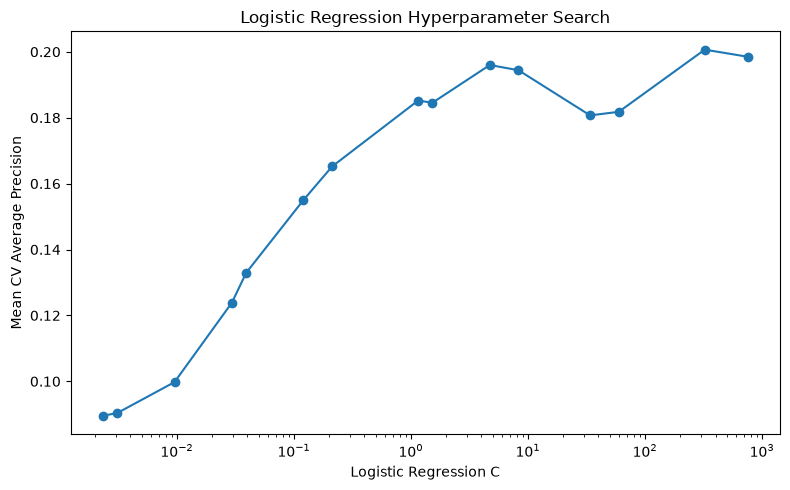

In [16]:
# plot
# let us see whether performance improves consistently as regularization weakens, if there's a clear best/optimum, or it's basically flat over a wide range
# using log x-axis is the right way to do this because C was searched over many orders of magnitude
cv_results_sorted = cv_results.sort_values("param_model__C")

plt.figure(figsize=(8, 5))

plt.plot(
    cv_results_sorted["param_model__C"],
    cv_results_sorted["mean_test_score"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("Logistic Regression C")
plt.ylabel("Mean CV Average Precision")
plt.title("Logistic Regression Hyperparameter Search")

plt.tight_layout()
plt.show()

### Logistic regression tuning results

Average precision improved well as the regularization weakened. The best sampled value was `C = 323.75`, with mean cross-validation average precision of `0.201`.

But several higher `C` values performed similarly, and cross-validation variability was substantial likely because the training data contain relatively few churn events. So, the exact winning value might not be interpreted as uniquely the best or optimal. But the search shows that relatively weak regularization performs best for this baseline model.

## Out-of-fold Predictions
- Now we will get a more "honest" prediction for each training observation from a model that did not train on that observation.
- This will get us a validation-like set of predictions
- As noted above, this is useful given that we want to avoid sacrificing more data for a separate validation set
- The following code will take each of our 5 folds: (1) fit the tuned pipeline on the other four folds, (2) predict churn probabilities for the held out fold, and (3) combine all five helt out predictions
- So, every row recieves a probability from a model that *never saw that row during fitting*
- And this is what we need before any threshold tuning

In [17]:
best_logistic_model = logistic_search.best_estimator_

oof_probabilities = cross_val_predict(
    best_logistic_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

## Evaluate the OOF probabilities
- I'll be using `ROC-AUC`, `Average Precision`, `Brier Score`, `Log Loss`
- `ROC-AUC` = overall ability to rank churners above the non-churners
- `Average Precision` = ranking performance that is focused on the rare churn class
- `Brier score` = accuracy of the actual predicted probabilities. Note that lower is better here.
- `Log loss` = penalize incorrect probability estimates, especially confident wrong predictions. Lower is also better
- Note that I won't use precision/recall at a threshold yet because these metrics evaluate the underlying probability/ranking model independently of a decision cutoff

In [18]:
oof_roc_auc = roc_auc_score(y_train, oof_probabilities)
oof_average_precision = average_precision_score(y_train, oof_probabilities)
oof_brier = brier_score_loss(y_train, oof_probabilities)
oof_log_loss = log_loss(y_train, oof_probabilities)

print(f"OOF ROC-AUC: {oof_roc_auc:.4f}")
print(f"OOF Average Precision: {oof_average_precision:.4f}")
print(f"OOF Brier Score: {oof_brier:.4f}")
print(f"OOF Log Loss: {oof_log_loss:.4f}")

OOF ROC-AUC: 0.7829
OOF Average Precision: 0.1481
OOF Brier Score: 0.0614
OOF Log Loss: 1.0664


### Out-of-fold performance

The tuned logistic regression achieved an OOF ROC-AUC of **0.783** and average precision of **0.148**. Given the low churn observations, this would indicate a fairly useful ability to rank higher-risk users.

But the Brier score (**0.061**) and log loss (**1.066**) might suggest that the raw probability estimates could be poorly calibrated. This is important because my project will ultimately use churn probabilities for decision-making and not just ranking.

**We should evaluate probability calibration before selecting an operational classification threshold**

**Additional Notes:**
- RandomizedSearchCV AP = 0.2 but the pooled OOF AP = 0.148. RandomizedSearchCV will report the average of the AP calculated separately in each individual CV fold. But here we just calculated AP once after pooling all the OOF predictions together. Also AP is nonlinear: `mean(AP across folds) != AP(all OOF predictions pooled)`. And there is some model selection differences/optimism because we chose the `C` that had the best CV result.

## Build Trivial Probability Baseline for Comparison
- We can now make a baseline predicting the training churn prevalance for each user
- The baseline will help determine if our model is actually producing better probabilities than simply predictin the same ~3.6% churn probability for everyone
- This will help us understand and interpret the Brier score and to figure out if the model useful regardless of how well it seems to rank

In [19]:
# baseline
baseline_probability = y_train.mean()

baseline_probabilities = np.full(
    len(y_train),
    baseline_probability
)

baseline_brier = brier_score_loss(
    y_train,
    baseline_probabilities
)

baseline_log_loss = log_loss(
    y_train,
    baseline_probabilities
)

print(f"Churn prevalence: {baseline_probability:.4f}")
print(f"Baseline Brier Score: {baseline_brier:.4f}")
print(f"Model Brier Score: {oof_brier:.4f}")
print()
print(f"Baseline Log Loss: {baseline_log_loss:.4f}")
print(f"Model Log Loss: {oof_log_loss:.4f}")

Churn prevalence: 0.0365
Baseline Brier Score: 0.0352
Model Brier Score: 0.0614

Baseline Log Loss: 0.1567
Model Log Loss: 1.0664


In [20]:
# check out the probability distribution
pd.Series(oof_probabilities).describe(
    percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
)

count     2.164000e+03
mean      5.237352e-02
std       2.133051e-01
min      9.979006e-264
50%       6.220292e-18
75%       3.176662e-10
90%       2.522838e-04
95%       5.114535e-01
99%       1.000000e+00
max       1.000000e+00
dtype: float64

### Probability baseline comparison

The tuned logistic regression ranks churn risk reasonably well, but its raw probabilities are poorly calibrated.

A trivial baseline that predicts the training churn prevalence for every customer achieved a **Brier score of 0.0352** and **log loss of 0.1567**, while the logistic regression produced substantially worse values of **0.0614** and **1.0664**, respectively.

The predicted probability distribution shows why this happened. Most users receive very low churn probabilities, while a small subset of them receive extremely high probabilities: the 95th percentile exceeds 50% and the 99th percentile is effectively 100%, despite overall churn prevalence being only about 3.6%.

This suggests that the model has useful ranking ability but is too overconfident. 

Probability calibration should be evaluated before using these probabilities for any decision-making or threshold selection.

## Calibration Curve
- Visualize whether predicted probabilities line up with the observed churn rates
- My code below will group users into bins based on predicted risk and compares the average predicted churn probability vs. the actual observed churn rate.
- So if the model was calibrated well, then the points would sit clsoe to the diagonal line. But considering our Brier and log-loss scores I would expect considerable amount of deviation
- Note that I will use `strategy = "quantile"` here because the churn events are rare. This will give each bin roughly similar numbers of observations which is more stable than eqaul width probability bins

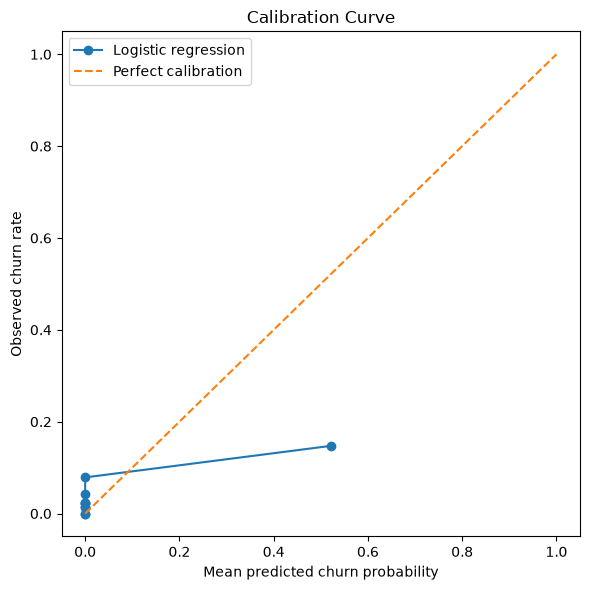

In [21]:
prob_true, prob_pred = calibration_curve(
    y_train,
    oof_probabilities,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted churn probability")
plt.ylabel("Observed churn rate")
plt.title("Calibration Curve")

plt.legend()
plt.tight_layout()
plt.show()

### Calibration Results

The calibration curve confirms that the logistic regression probabilities are substantially overconfident.

While the model has useful ranking ability, its predicted churn probabilities do not align well with our observed churn rates. In the higher-risk bins, predicted probabilities are much larger than the actual churn rates.

And this is consistent with the poor Brier score and log loss relative to the prevalence baseline we created. The model may therefore be useful for ranking customers by churn risk, but its raw probabilities should not yet be interpreted as reliable estimates of absolute churn probability.

## Calibrate the Tuned Logistic Regression Model
- we can calibrate with cross-validation so we don't leak information
- I will try `sigmoid calibration`. This is because the dataset is small and churn is rare. Note that `isotonic calibration` might be flexible but from my research it can overfit when there are few positive events.
- The code below will create a calibrated version of the tuned logistic pipeline. It doesn't fit.
- The sigmoid will learn a mapping from the raw model scores to better-behaved probabilities. It should generally need less data than isotonic.

In [22]:
calibrated_logistic_model = CalibratedClassifierCV(
    estimator=best_logistic_model,
    method="sigmoid",
    cv=cv
)

## Out-of-fold calibrated probabilities

Now to evaluate calibration without using the final test set we can generate out-of-fold probabilities from the calibrated logistic model.

Each training observation receives a probability from a model that was fit and calibrated without using that observation.

The code below will create the calibrated version of the OOF process I used above. For each fold, we fit the calibrated logistic model on the other folds and predict probabilities for the held-out fold. That will give us a fair set of calibrated probabilities for every training observation. 

In [23]:
calibrated_oof_probabilities = cross_val_predict(
    calibrated_logistic_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

**Now compare the calibrated model against the original model and the trivial prevalence baseline**

In [24]:
calibrated_roc_auc = roc_auc_score(
    y_train,
    calibrated_oof_probabilities
)

calibrated_average_precision = average_precision_score(
    y_train,
    calibrated_oof_probabilities
)

calibrated_brier = brier_score_loss(
    y_train,
    calibrated_oof_probabilities
)

calibrated_log_loss = log_loss(
    y_train,
    calibrated_oof_probabilities
)

print(f"Calibrated OOF ROC-AUC: {calibrated_roc_auc:.4f}")
print(f"Calibrated OOF Average Precision: {calibrated_average_precision:.4f}")
print(f"Calibrated OOF Brier Score: {calibrated_brier:.4f}")
print(f"Calibrated OOF Log Loss: {calibrated_log_loss:.4f}")

Calibrated OOF ROC-AUC: 0.7817
Calibrated OOF Average Precision: 0.1454
Calibrated OOF Brier Score: 0.0338
Calibrated OOF Log Loss: 0.1417


In [25]:
# create summary comparison table
calibration_comparison = pd.DataFrame({
    "Model": [
        "Prevalence baseline",
        "Uncalibrated logistic",
        "Calibrated logistic"
    ],
    "Brier Score": [
        baseline_brier,
        oof_brier,
        calibrated_brier
    ],
    "Log Loss": [
        baseline_log_loss,
        oof_log_loss,
        calibrated_log_loss
    ]
})

calibration_comparison

,Model,Brier Score,Log Loss
0,Prevalence baseline,0.035174,0.156678
1,Uncalibrated logistic,0.061367,1.066430
2,Calibrated logistic,0.033809,0.141710


### Calibration improvement

Sigmoid calibration substantially improved the quality of the logistic regression probability estimates while preserving nearly all of the model's ranking ability.

ROC-AUC changed only slightly from **0.783 to 0.782**, and average precision from **0.148 to 0.145**. In contrast, probability-quality metrics improved dramatically:

- Brier score improved from **0.0614** to **0.0338**
- Log loss improved from **1.0664** to **0.1417**

The calibrated model also slightly outperformed the prevalence-only baseline on both metrics.

This indicates that the original logistic regression contained useful churn-ranking signal, but its raw probabilities were severely overconfident. Sigmoid calibration corrected much of this distortion without materially changing customer risk ordering.

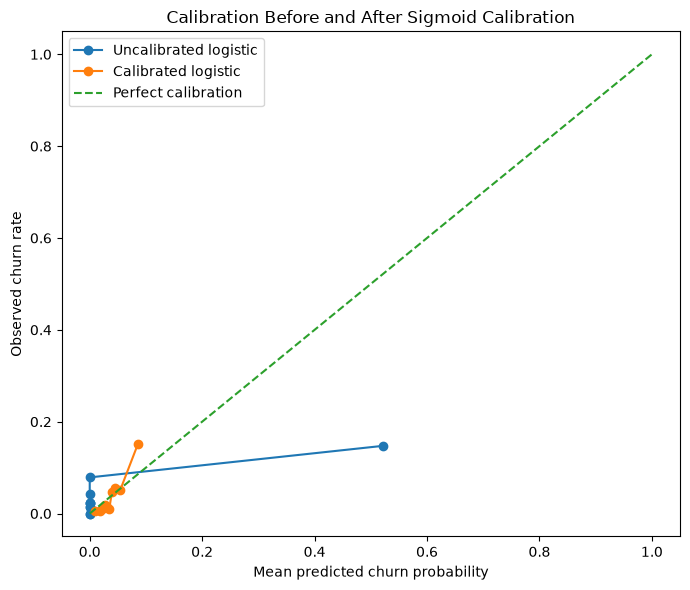

In [26]:
# we can visualize the before vs after calibration
uncal_true, uncal_pred = calibration_curve(
    y_train,
    oof_probabilities,
    n_bins=10,
    strategy="quantile"
)

cal_true, cal_pred = calibration_curve(
    y_train,
    calibrated_oof_probabilities,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    uncal_pred,
    uncal_true,
    marker="o",
    label="Uncalibrated logistic"
)

plt.plot(
    cal_pred,
    cal_true,
    marker="o",
    label="Calibrated logistic"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted churn probability")
plt.ylabel("Observed churn rate")
plt.title("Calibration Before and After Sigmoid Calibration")

plt.legend()
plt.tight_layout()
plt.show()

**Observation/Results**: 

Sigmoid calibration substantially improves the relationship between predicted and observed churn probabilities. The calibrated predictions lie much closer to the ideal calibration line, particularly across the probability range containing most customers.

Some miscalibration remains in the highest-risk region, which is unsurprising given the small number of churn events. Overall, the calibrated logistic model provides much more credible probability estimates than the original model while preserving similar ranking performance.

    

### Visulaize Ranking Performance
- Show how well the model separates churners from non-churners across all thresholds. 

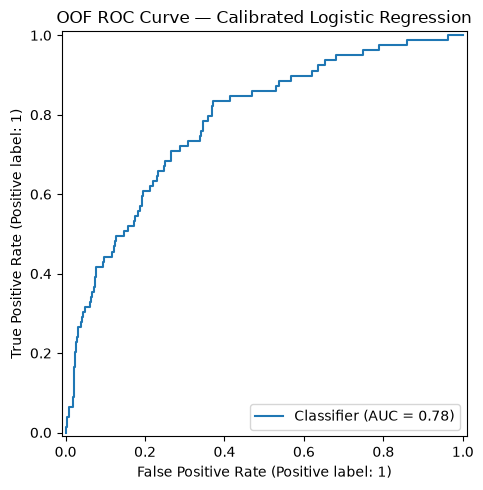

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_train,
    calibrated_oof_probabilities,
    ax=ax
)

ax.set_title("OOF ROC Curve — Calibrated Logistic Regression")

plt.tight_layout()
plt.show()

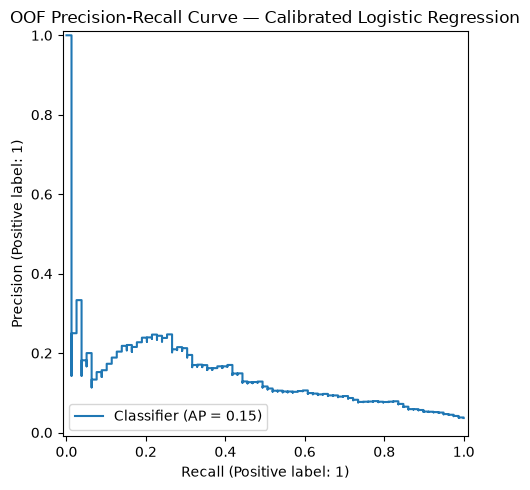

In [28]:
# precision recall display is important for our rare event problem
fig, ax = plt.subplots(figsize=(6, 5))

PrecisionRecallDisplay.from_predictions(
    y_train,
    calibrated_oof_probabilities,
    ax=ax
)

ax.set_title("OOF Precision-Recall Curve — Calibrated Logistic Regression")

plt.tight_layout()
plt.show()

**Notes:**
1. The ROC curve gives us a pretty good broad view of discrimination. But note that with only ~3.6% churn it can look pretty good even when precision is modest
2. The precision-recall curve is more informative here because it focuses on our rare positive class and can show the tradeoff we would eventually use for operational threshold selection

### Discrimination performance

The calibrated logistic regression shows useful ranking ability with an OOF ROC-AUC of approximately **0.78**.

The precision-recall curve is more informative for this rare-event problem. Average precision is approximately **0.15**, which is substantially above the churn prevalence baseline of roughly 3.6%, indicating that the model meaningfully concentrates churners toward the higher-risk portion of the ranking.

However, precision declines as recall increases. This nicely illustrates the operational tradeoff when selecting a treatment or intervention threshold.
- Note that before we do any threshold sweeps we will build a challenger model using catboost. The winner will be used in threshold selection

## Catboost
- Let's create a catboost challenger model and compare it to our baseline logistic regression model